Практична робота 10
Неперервні розподіли в scipy.stats
Виконавець: Войтович Богдан, IT-32
Варіант: 6 (Чернігів)



In [68]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

# Фіксуємо генератор випадкових чисел
np.random.seed(6)

# Липнева температура Чернігова з таблиці
mean_july_temp = 20

# Генеруємо вибірку денних температур: нормальний розподіл з μ=20, σ=2.5, n=30 днів
daily_temps = np.random.normal(loc=mean_july_temp, scale=2.5, size=30)

print("Сгенерована вибірка денних температур:")
print(np.round(daily_temps, 2))
print(f"Середнє вибірки: {daily_temps.mean():.2f}")
print(f"Стандартне відхилення вибірки: {daily_temps.std(ddof=1):.2f}")


Сгенерована вибірка денних температур:
[19.22 21.82 20.54 17.75 13.78 22.28 22.82 16.21 24.1  18.93 26.58 21.5
 19.16 23.09 20.28 20.32 20.19 19.61 21.59 22.03 20.89 24.53 16.61 18.84
 22.06 17.06 23.91 21.78 19.55 21.34]
Середнє вибірки: 20.61
Стандартне відхилення вибірки: 2.71


In [69]:
mean = daily_temps.mean()
std = daily_temps.std(ddof=1)

dist = stats.norm(loc=mean, scale=std)

print(f"Встановлені параметри нормального розподілу: μ={mean:.2f}, σ={std:.2f}")


Встановлені параметри нормального розподілу: μ=20.61, σ=2.71


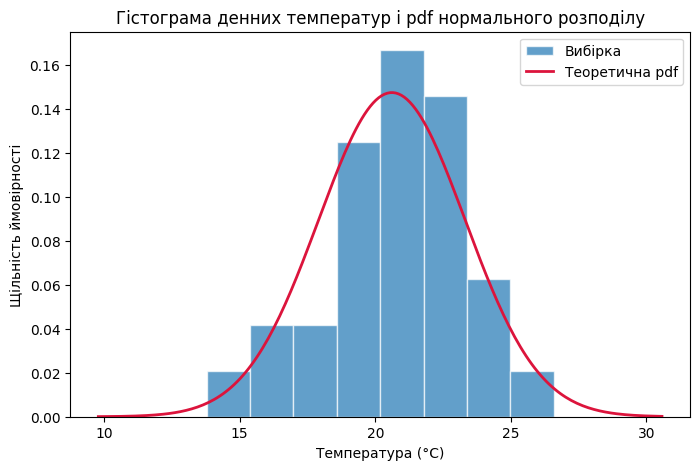

In [70]:
# Вісь X для pdf: трохи ширший за вибірку
x = np.linspace(daily_temps.min() - 4, daily_temps.max() + 4, 200)

fig, ax = plt.subplots(figsize=(8, 5))

# Гістограма з density=True
ax.hist(daily_temps, bins=8, density=True, edgecolor="white", alpha=0.7, label="Вибірка")

# Накладаємо pdf
ax.plot(x, dist.pdf(x), color="crimson", linewidth=2, label="Теоретична pdf")

ax.set_xlabel("Температура (°C)")
ax.set_ylabel("Щільність ймовірності")
ax.set_title("Гістограма денних температур і pdf нормального розподілу")
ax.legend()
plt.show()


In [71]:
p_interval = dist.cdf(mean + std) - dist.cdf(mean - std)
print(f"Ймовірність температури у межах одного стандартного відхилення: {p_interval:.3f}")

print("""
Значення близько до теоретичного правила 68%. Відхилення пов’язані з випадковістю конкретної вибірки n=30.
""")


Ймовірність температури у межах одного стандартного відхилення: 0.683

Значення близько до теоретичного правила 68%. Відхилення пов’язані з випадковістю конкретної вибірки n=30.



In [72]:
temp_95 = dist.ppf(0.95)
print(f"Температура для 95-го процентиля: {temp_95:.2f} °C")

print("""
.ppf() — обернена функція до .cdf(): на вході ймовірність, на виході — значення величини,
для якого накопичена ймовірність до нього дорівнює заданій (0.95 тут).
""")


Температура для 95-го процентиля: 25.06 °C

.ppf() — обернена функція до .cdf(): на вході ймовірність, на виході — значення величини,
для якого накопичена ймовірність до нього дорівнює заданій (0.95 тут).



Короткі відповіді на контрольні питання
.pdf(x) повертає щільність ймовірності в точці x, відповідає на питання "яка густина розподілу в цій точці?".
.cdf(x) — накопичена ймовірність до x, тобто ймовірність потрапити в інтервал (-∞, x].

Значення .pdf(x) може бути більшим за 1, бо це густина, а не ймовірність. Для неперервних розподілів густина може перевищувати 1, якщо розподіл "вузький" — ймовірність інтегрується по інтервалу.

.ppf() — обернена до .cdf(). На вході бере ймовірність p, а повертає значення x, для якого CDF(x)=p.